# App2 - Sleep apnea detection from ECG signal
DTEK2093-3002 Machine Learning Health Technology Project
- Cecilia Johansson


### ECG signal in detection of sleep apnea
Sleep apnea is a sleeping disorder where breathing is paused or weak during the sleep. This disorder consists of two phases: bradycardia and tachycardia which describe the heart rate. (2) In bradycardia the heart rate is slower than usual and in tachycardia the heart rate is faster than usual as normal heart rate is defined to be between 60 and 100 bpm. (3) If undiagnosed, sleep apnea can lead to adverse health conditions such as stroke or heart diseases. (1) Many sleep apnea cases are undiagnosed due to high cost and time-consuming processes and practical limitations as diagnose requires overnight detection performed by an expert. (2), (4)

ECG can offer a simple non-invasive solution making detection of sleep apnea easier and cost-effective (4). To identify sleep apnea, HRV features can be extracted from the ECG (1). Sleep apnea episodes can be recognised from the heart rate as the lack of breathing during bradycardia can be seen as slow heart rate, and after the apnea episode the breathing continues meaning that the heart rate goes up during tachycardia. (2) 

In this project, the aim was to analyse ECG data from patients with and without sleep apnea by first preprocessing the data, detecting R-peaks and finally applying machine learning algorithms. The data included patients with obstructive sleep apnea meaning that the breathing is completely stopped during the apnea episode. 

In [2]:
# All imports
import os
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import interpolate
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
# from xgboost import XGBClassifier 
# from sklearn.linear_model import LogisticRegression

##### Data format
From one to several records were collected from 64 subjects which represented either normal or apnea data. The data was already split into the test and train data folders, and each record included 5 minutes of ECG signal produced by a single lead setup. Data was in the form of e.g. "22_subj10.txt" from which the first number described the event and the second described the subject number.

In [3]:
# Paths to datasets
apnea_train = "Data/Train/apnea/"
apnea_test =  "Data/Test/apnea/"
normal_train =  "Data/Train/normal/"
normal_test =  "Data/Test/normal/"

In [4]:
# Check the data format
print(os.listdir('Data/Train/apnea')[0])
print(os.listdir('Data/Train/apnea')[20])
print(os.listdir('Data/Train/apnea')[7])

0_subj1.txt
118_subj27.txt
106_subj22.txt


In [12]:
# Here are all the functions

# Load the data and keys
def load_data(path):
    data1 = os.listdir(path)
    data = defaultdict(list) # Automaticly initializes missing values
    avaimet = []
    
    # Go through all files with data
    for f in data1:
        subj = f.split('_')[1].replace('.txt', '')   # 0_subj1.txt --> subj1
        # Load the ecg data and add it to list of data
        filepath = os.path.join(path, f)
        data[subj].append(np.loadtxt(filepath))
    # Add keys to their own list
    avaimet = list(data.keys())
    return data, avaimet

# Clean the ECG signal from noise by neurokit method which includes 0.5 Hz high-pass butterworth filter of order 5
def clean_signal(signaali, fs):
    clean = nk.ecg_clean(signaali, sampling_rate=fs, method="neurokit")
    return clean

# Smooth the cleaned and preprocessed signal
def interpolation(signal, old_fs, new_fs):
    interpol = interpolate.interp1d(old_fs, signal, kind='cubic', fill_value='extrapolate')
    interpolated = interpol(new_fs)
    return interpolated

# Here we preprocess the data: remove noise and artifacts, segment, and resample for better results in RR/HRV
def preprocess(signal_data, old_fs=100, new_fs=1000):
    preprocessed = {}
    
    fs1 = old_fs
    fs2 = new_fs
    
    for avain, data in signal_data.items():
        new_segments = []
        
        for signal in data:
            cleaned_signal = clean_signal(signal, fs=fs1)
            
            # First calculate sample per minute
            sample_minute = fs1 * 60
            newer_sample_minute = fs2 * 60
            all_segments = len(cleaned_signal) // sample_minute
            
            for segment in range(all_segments):
                
                 # We get new segment by defining the start and end point in the cleaned signal data
                new_segment = cleaned_signal[(segment*sample_minute):((segment+1)*sample_minute)]
                
                # Here we ensure evenly spaced arrays with specific number of data 
                # Resample from 100Hz to 1000Hz
                old_fs1 = np.linspace(0, 60,num=len(new_segment), endpoint=False)
                new_fs2 = np.linspace(0, 60, num=newer_sample_minute, endpoint=False)
                
                # Do the interpolation
                resampled = interpolation(new_segment, old_fs1, new_fs2)
                new_segments.append(resampled)
                
            preprocessed[avain] = new_segments
    return preprocessed

# Peak detection for cleaned data
def detect_peaks(cleaned_signal, fs):
    r_peaks = {}
    for avain, data in cleaned_signal.items():
        peaks = []
        for signal in data:
            _, rr_peaks = nk.ecg_peaks(signal, sampling_rate=fs)
            peaks.append(rr_peaks['ECG_R_Peaks'])
        r_peaks[avain] = peaks
    return r_peaks


# Plot the detected peaks and use ecg.process() to get broader picture
def plot_peaks(cleaned_signal, r_peaks, name):
    
    plt.rcParams["figure.figsize"] = (20, 6) # This makes the ecg_process pictures better scale
    signals, info = nk.ecg_process(cleaned_signal)
    nk.ecg_plot(signals, info)
    plt.title(name)
    plt.show()

    plt.figure(figsize = (20,7))
    plt.plot(cleaned_signal, label='ECG signal')
    plt.scatter(r_peaks, [cleaned_signal[p] for p in r_peaks], color='red', zorder=5, label="R-peaks")
    plt.title(name)
    plt.xlabel('Index')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Here we extract time- and frequency-domain HRV features using Neurokit functions and concatenate them
def define_HRV_features(r_peaks, fs):
    right_form = {"ECG_R_Peaks": np.array(r_peaks)}
    time_hrv = nk.hrv_time(right_form, sampling_rate=fs, show=False)
    freq_hrv = nk.hrv_frequency(right_form, sampling_rate=fs)
    all_features = pd.concat([time_hrv[['HRV_MeanNN','HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_SDSD', 'HRV_MedianNN', 'HRV_IQRNN']], freq_hrv[['HRV_LF', 'HRV_HF', 'HRV_LFHF']]], axis=1)
    return all_features

# We make dataframe of the HRV features, and return patient id's for further use
def hrv_dataframe(r_peaks, fs):
    frame = []
    patient_id = []
    for avain, data in r_peaks.items():
        for segment in data:
            if len(segment) < 2:
                print(f"Skip, there isn't enough peaks in {avain}")
                continue
            hrv_features = define_HRV_features(segment, fs)
            frame.append(hrv_features)
            patient_id.append(avain)
    final_frame = pd.concat(frame, ignore_index=True)
    return final_frame, patient_id

# Apply machine learning methods and model evaluation for the preprocessed data
def predict_and_evaluate_all(X, y, X_test, y_test, model, group):
    
    trues = []
    preds = []
    prob_for_apnea = []
    importances = []
    logo = LeaveOneGroupOut()
    replace_by_mean = SimpleImputer(strategy="mean")
    
    for train_idx, test_idx in logo.split(X, y, group):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Replace nan-values so all the classifiers work here
        X_train = replace_by_mean.fit_transform(X_train)
        X_test = replace_by_mean.transform(X_test)
        
        # Scale numerical features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        prob = model.predict_proba(X_test)
        
        # Calculate the importances
        importance = permutation_importance(model, X_test, y_test, n_repeats=10) # repeat 5 times to save time
        mean = importance.importances_mean
        importances.append(mean)
        
        trues.extend(y_test)
        preds.extend(y_pred)
        prob_for_apnea.extend(prob[:,1]) # The probability that the patient has apnea
        
    # Here we measure the probability of correctly classifying apnea patients
    accuracy = accuracy_score(trues, preds)
    precision = precision_score(trues, preds)
    recall = recall_score(trues, preds)
    f1 = f1_score(trues, preds)
    auc = roc_auc_score(trues, prob_for_apnea) # This
    
    # Here we calculate and plot the feature importances
    features = ['HRV_MeanNN','HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_SDSD', 'HRV_MedianNN', 'HRV_IQRNN','HRV_LF', 'HRV_HF', 'HRV_LFHF']
    importances = np.array(importances)
    importances = np.mean(importances, axis=0)
    plt.figure(figsize=(10,5))
    plt.barh(features, importances, color='skyblue')
    plt.title("Importance of features")

    # Print the results
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 score: {f1:.3f}")
    
    # Confusion matrix to visualize results
    conf = confusion_matrix(trues, preds)
    cm_d = ConfusionMatrixDisplay(conf, display_labels = ['Normal', 'Apnea'])
    cm_d.plot()
    
    # AUC to visualize the classifier´s performance
    print(f"AUC: {auc:.3f}")
    RocCurveDisplay.from_predictions(trues, prob_for_apnea)
    plt.show()

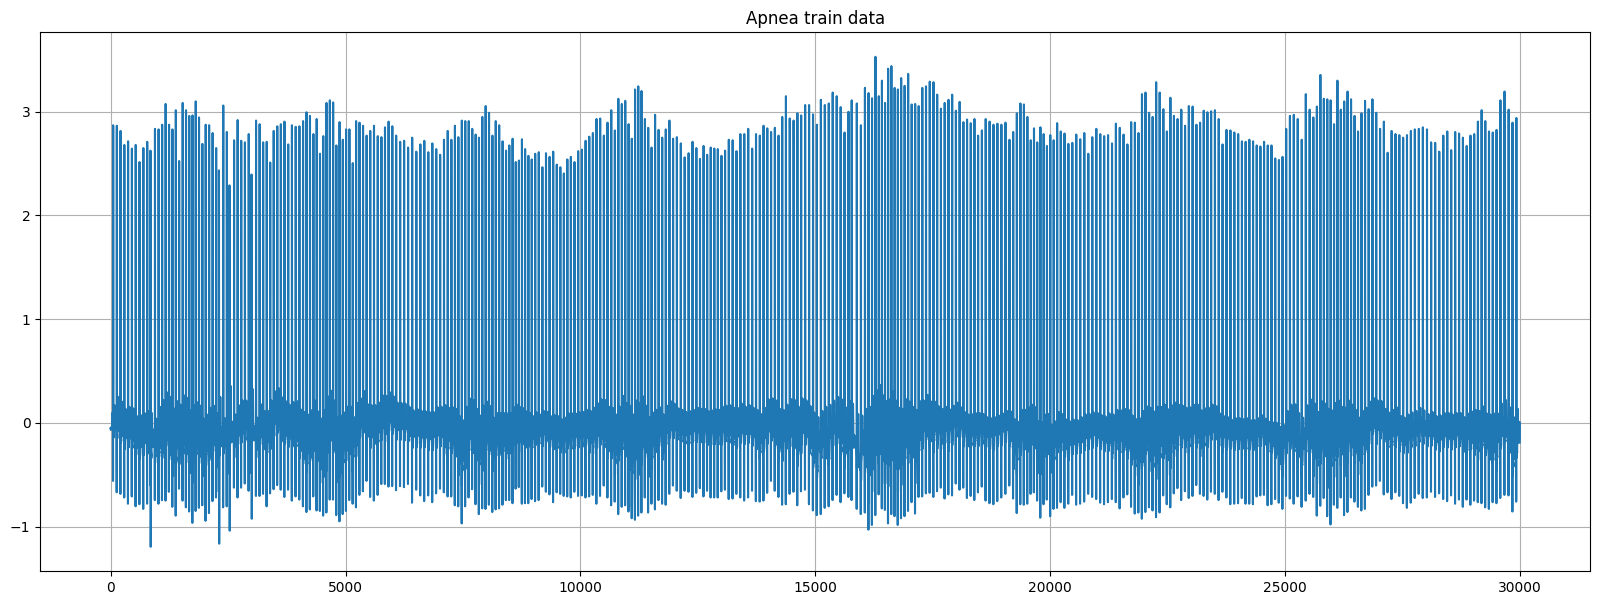

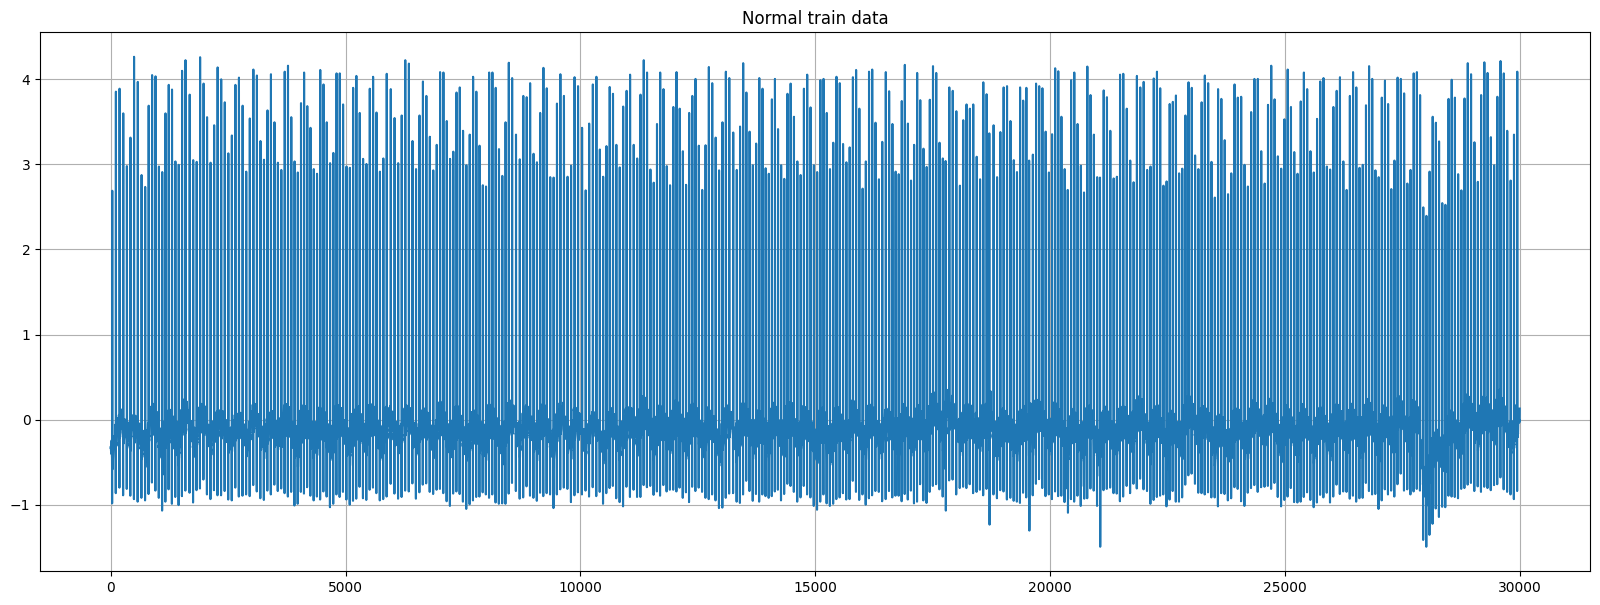

In [6]:
# See what the raw data looks like
apnea, avaimet = load_data(apnea_train)
normaali, avaimet1 = load_data(normal_train)

# Here we take one example of normal and apnea
plt.figure(figsize=(20,7))
plt.plot(apnea[avaimet[0]][1])
plt.title("Apnea train data")
plt.grid(True)

plt.figure(figsize=(20,7))
plt.plot(normaali[avaimet1[0]][1])
plt.title("Normal train data")
plt.grid(True)
plt.show()


###### Evaluation of the raw data

Even before preprocessing the data, there can be seen significant difference between the normal and apnea data. The normal data shows steady pattern with regular ups and downs through the whole graph. The apnea data, on the other hand, has a regular pattern which has much broader ups and downs indicating that the heart beat is significantly higher or slower.

#### Load and preprocess of the data
Based on the data format, load_data() function returns the data with the keys (subject id), and defaultdict() assigns the data for the right subject. Neurokit package was chosen in removing noise and baseline drift using neurokit method which is order 5 high-pass butterworth filter in the range of 0.5-50 Hz. Neurokit method was chosen based on Tyagi's and Agrawal's (1) observations which showed that the range of 0.5-40 Hz bandpass filter works for preprosessing of ECG data for sleep apnea as factors like ECG equipment or electromagnetic interferences might disturb the signal under 0.5 Hz and over 40 Hz. Furthermore, cubic interpolation was chosen to smooth the data as Daskalov and Christov (5) observed that the cubic interpolation can remove noise/baseline drift and improve resolution. 

In the preprocess() function, each signal from the data is preprocessed by first removing noise and baseline drift by filtering. ECG signal was segmented into 1-minute segments, like in several studies e.g. (1), to make analyzation of the signal easier. Moreover, as the ECG-records were digitized at 100 Hz, the signal was resampled at 1000 Hz to further improve the presentation of the signal. Resampled signal was then interpolated.

#### Detection of R-peaks

In R-peak detection, preprocessed signal served as an input to detect_peaks() function which used nk.ecg_peaks() Neurokit function to detect peaks. R-peaks were plotted by the plot_peaks() function which included Neurokit function nk.ecg_process() that gave broader illustrations of the signal e.g., heart rate variation. 

C:\Users\Cecilia\Documents\Sovellukset\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)
C:\Users\Cecilia\Documents\Sovellukset\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError

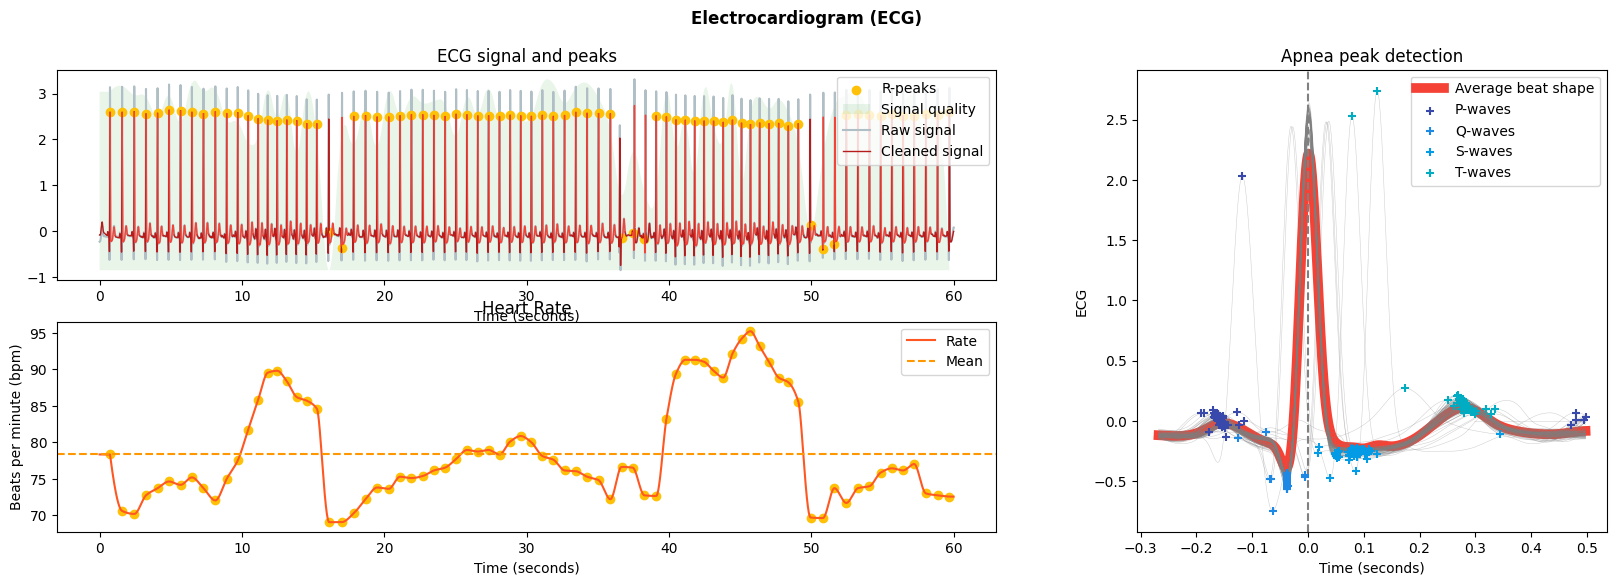

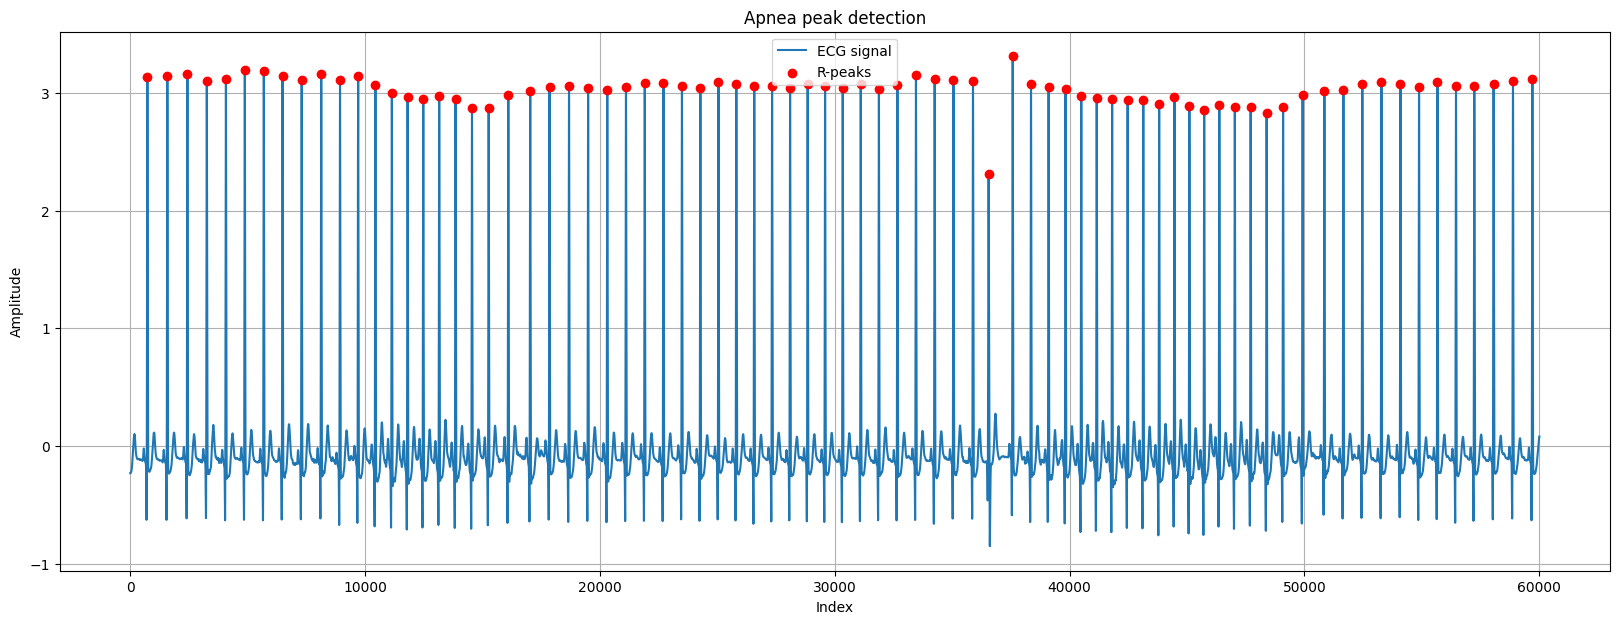

C:\Users\Cecilia\Documents\Sovellukset\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  buffer.select_dtypes(exclude="int64").replace({0.0: np.nan}, inplace=True)
C:\Users\Cecilia\Documents\Sovellukset\Lib\site-packages\neurokit2\epochs\epochs_create.py:172: ChainedAssignmentError

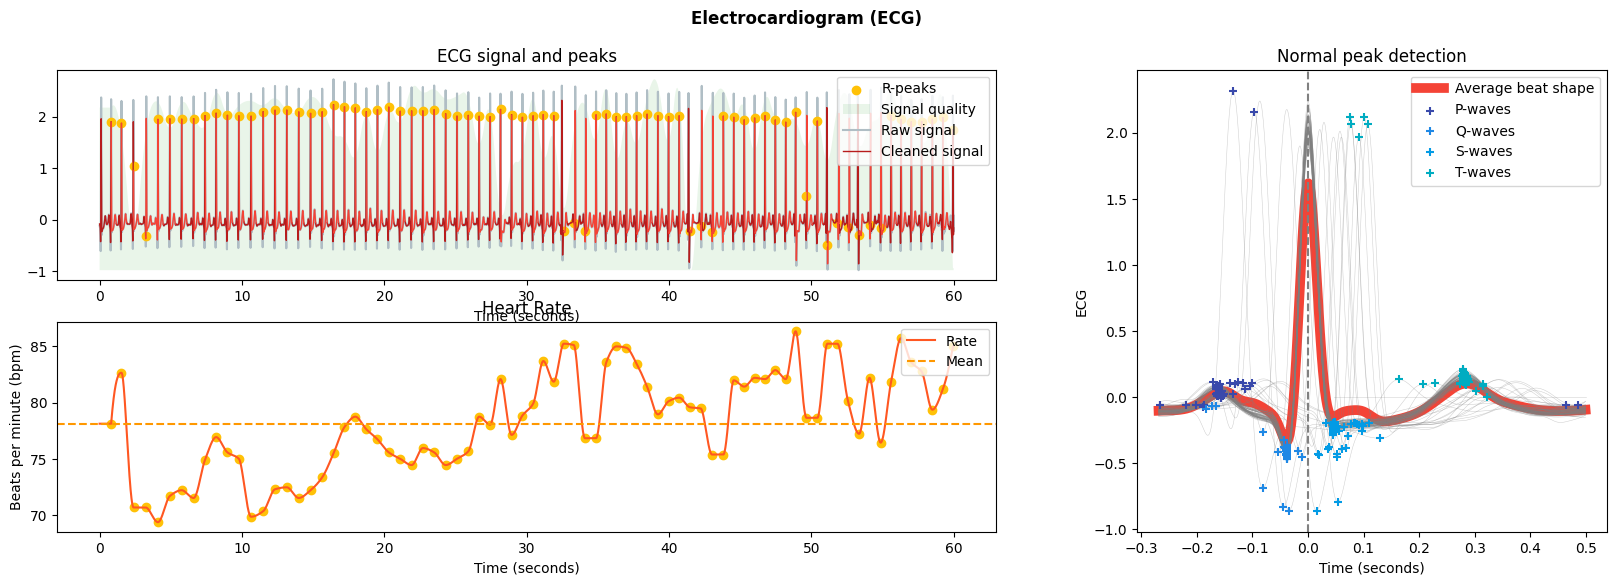

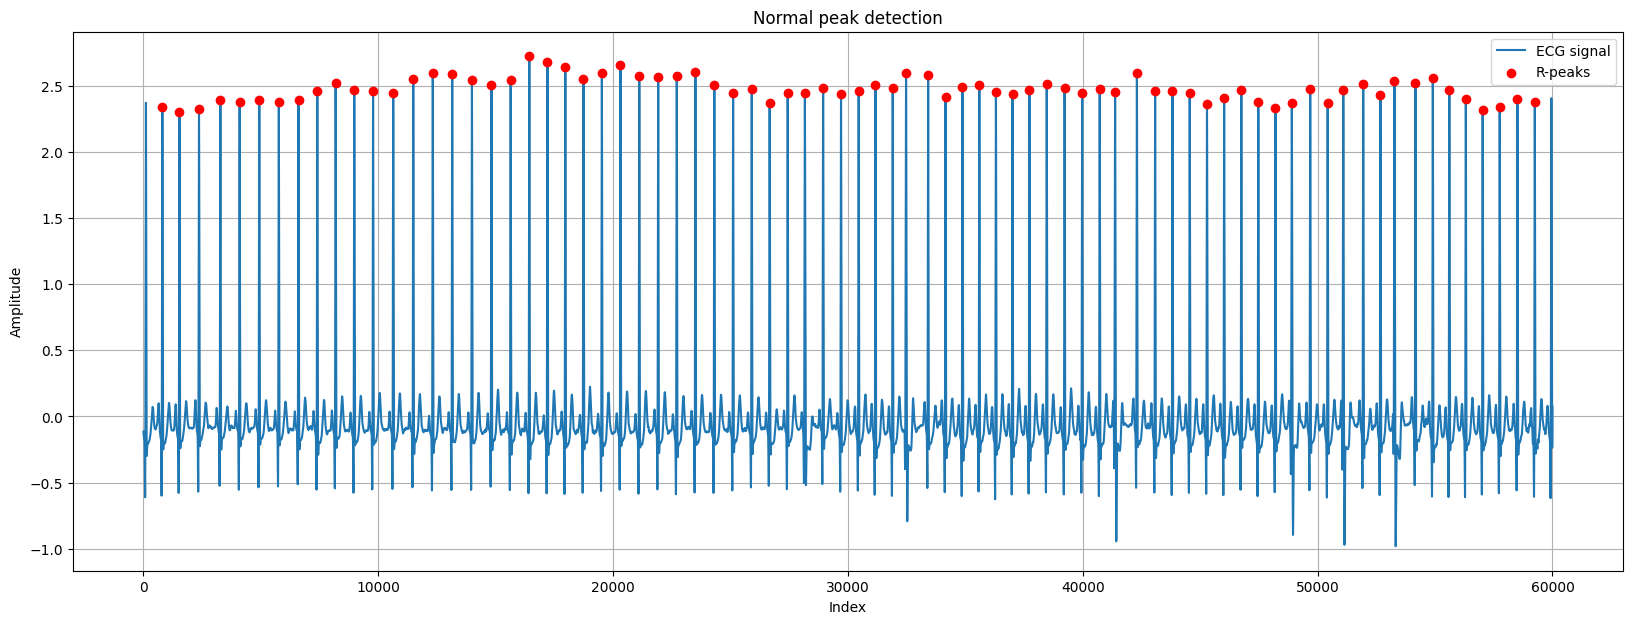

In [13]:
# Here we preprocess, detect and plot the peaks
new_fs = 1000
old_fs = 100

apnea_data = preprocess(apnea, old_fs, new_fs)
normal_data = preprocess(normaali, old_fs, new_fs)

ap_peak = detect_peaks(apnea_data, new_fs)
nor_peak = detect_peaks(normal_data, new_fs)

ap = plot_peaks(apnea_data[avaimet[0]][1], ap_peak[avaimet[0]][1], "Apnea peak detection")
nor = plot_peaks(normal_data[avaimet1[0]][1], nor_peak[avaimet1[0]][1], "Normal peak detection")

#### Evaluation of the preprocessed data

The heart rate graph shows that the apnea patients heart rate varies between 70-95 as the normal patients heart rate is between 70-85. Also, the apnea data shows steep rises and declines e.g., from under 75 above 90, where as the normal data shows more regularly smaller rises and declines. From preprocessed ECG signals it can be seen that the amplitude of apnea data is higher than the amplitude of normal data. This can be due to higher stress of the heart. More compressed areas can be distinguished from the apnea data between 10000-15000 and 40000-50000. 

#### Extraction of HRV features
Based on the articles (2), (4), (6), the following time-domain features are extracted in all of them for sleep apnea detection: RMSSD, pNN50, and SDNN. From frequency-domain, features like LF, HF, and LF/HF ratio were extracted (6). In addition to these features, we decided to extract other features mentioned: pNN20, SDSD, Median NN and IQRNN. Non-linear features weren't extracted as in some of the articles those weren't extracted (2), (4), and the extraction of non-linear features turned out to be challenging. Here are the explanations of the HRV features we chosed to use:

The explanations are from (7), (2), :
- SDNN - Standard deviation of the difference between RR-intervals
- RMSSD - Root mean square of the difference between RR-intervals
- pNN50 - Percentage of RR-intervals which differ more than 50 ms
- pNN20 - Percentage of RR-intervals which differ more than 20 ms
- SDSD - Standard deviation of the difference between adjacent RR-intervals
- IQRNN - Inter-quartile range means difference between 25-75 percentiles of RR-interval value distribution
- Median NN - Median of RR-intervals
- LF - low heart rate variability (0.04-0.15 Hz)
- HF - high heart rate variability (0.15-0.4 Hz)
- LF/HF ratio - ratio between high and low heart rate variability

Time- and frequency-domain HRV features were extracted using Neurokit functions nk.hrv_time() and nk.hrv_frequency(), and concatenated for the joint dataframe. In hrv_dataframe() function, dataframe was constructed and invalid segments were skipped so that the classifiers could handle the features from there. Before applying machine learning, the train and test data were shuffled to get more reliable results. 

In [165]:
# Here we load, preprocess and detect peaks from test data also
apnea_test, avaimet2 = load_data(apnea_test)
normaali_test, avaimet3 = load_data(normal_test)

apnea_data_test = preprocess(apnea_test, old_fs, new_fs)
normal_data_test = preprocess(normaali_test, old_fs, new_fs)

ap_peak_test = detect_peaks(apnea_data_test, new_fs)
nor_peak_test = detect_peaks(normal_data_test, new_fs)

# Here are all the dataframes
apnea_data_hrv, patient1 = hrv_dataframe(ap_peak, new_fs)
normal_data_hrv, patient2 = hrv_dataframe(nor_peak, new_fs)
apnea_data_test_hrv, patient3 = hrv_dataframe(ap_peak_test, new_fs)
normal_data_test_hrv, patient4 = hrv_dataframe(nor_peak_test, new_fs)

# Example display of train apnea
display(apnea_data_hrv)

# Here we define dataframe so that there is also columns "Patient" and "Label" to define patient id and apnea or normal
apnea_data_hrv['label'] = 1
normal_data_hrv['label'] = 0
apnea_data_test_hrv['label'] = 1
normal_data_test_hrv['label'] = 0

apnea_data_hrv['patient_id'] = patient1
normal_data_hrv['patient_id'] = patient2
apnea_data_test_hrv['patient_id'] = patient3
normal_data_test_hrv['patient_id'] = patient4

# Here we make concatenated dataframe for train and test so that we can use with ML methods and evaluation
train = pd.concat([apnea_data_hrv, normal_data_hrv])
test = pd.concat([apnea_data_test_hrv, normal_data_test_hrv])

Skip, there isn't enough peaks in subj6


,HRV_MeanNN,HRV_RMSSD,HRV_SDNN,HRV_pNN50,HRV_pNN20,HRV_SDSD,HRV_MedianNN,HRV_IQRNN,HRV_LF,HRV_HF,HRV_LFHF
0,734.283951,24.943687,66.900343,6.172840,23.456790,25.090088,725.0,115.00,0.008547,0.003629,2.354991
1,765.883117,64.352442,74.453266,11.688312,27.272727,64.779258,785.0,113.00,0.046428,0.023274,1.994879
2,779.276316,32.117700,60.801886,9.210526,39.473684,32.329960,786.5,92.25,0.010251,0.020937,0.489612
3,786.706667,32.102244,82.794727,6.666667,36.000000,32.241410,809.0,89.50,0.023232,0.005598,4.150072
4,795.067568,35.416891,90.289539,5.405405,36.486486,35.508011,825.5,82.25,0.030511,0.003308,9.222399
...,...,...,...,...,...,...,...,...,...,...,...
1459,946.887097,302.348946,202.739687,53.225806,75.806452,304.710430,975.0,230.50,0.005183,0.140480,0.036893
1460,975.750000,322.898840,235.759546,36.666667,63.333333,325.670252,930.0,127.75,0.053887,0.059700,0.902616
1461,926.812500,196.228689,151.102601,15.625000,46.875000,197.803031,913.0,94.50,0.046387,0.083421,0.556053
1462,923.718750,33.210010,62.203830,10.937500,50.000000,33.449123,923.0,63.25,0.002852,0.008172,0.348972


In [166]:
# Shuffle the dataframe data for ML methods
train = train.sample(frac=1).reset_index(drop=True)
test = test.sample(frac=1).reset_index(drop=True)
display(train)

,HRV_MeanNN,HRV_RMSSD,HRV_SDNN,HRV_pNN50,HRV_pNN20,HRV_SDSD,HRV_MedianNN,HRV_IQRNN,HRV_LF,HRV_HF,HRV_LFHF,label,patient_id
0,729.700000,9.134023,63.976736,0.000000,5.000000,9.048895,730.5,108.00,0.002545,0.000270,9.431449,0,subj47
1,836.200000,17.251339,34.371626,0.000000,24.285714,17.368394,839.0,47.50,0.024161,0.017113,1.411831,0,subj40
2,878.656716,30.951086,72.168900,8.955224,37.313433,31.155225,877.0,106.50,0.008017,0.002933,2.733412,1,subj2
3,825.042254,27.289977,73.372131,8.450704,26.760563,27.479727,836.0,116.00,0.011629,0.003528,3.295979,0,subj13
4,952.645161,21.483886,34.933706,1.612903,16.129032,21.351943,958.5,43.25,0.011853,0.007020,1.688539,1,subj29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114,764.155844,32.877964,33.328534,9.090909,62.337662,33.096104,755.0,45.00,0.005553,0.058951,0.094196,0,subj6
3115,796.581081,13.708312,45.827851,0.000000,10.810811,13.754465,798.0,65.50,0.006683,0.001604,4.167606,1,subj60
3116,735.962500,62.353220,44.638476,7.500000,10.000000,62.751021,731.0,29.25,0.008319,0.018914,0.439840,0,subj1
3117,873.761194,8.811150,38.124235,0.000000,1.492537,8.872314,886.0,31.00,0.006059,0.000368,16.462584,0,subj47


In [167]:
# Before applying ML we should segment the data correctly

# Here are all HRV numerical features
X_train = train.drop(['label', 'patient_id'], axis=1).values
X_test = test.drop(['label', 'patient_id'], axis=1).values

# Here is the label Normal or Apnea
y_train = train['label'].values
y_test = test['label'].values

# Define the groups to be used in LOGO
groups = train['patient_id'].values

#### Applying machine learning methods, and standardizing the data

This process could have been split into several functions to make the presentation more clear, but this time one function performed all as the calculations weren't significantly heavy. LeaveOneGroupOut cross-validation method was used to reduce overfitting and improve generalization performance. In this validation method, one group (one subject) is left out for testing as a subject can be presented many times in the dataframe. SimpleImputer() function was used to replace nan-values with the mean of train/test values as some machine learning methods couldn't handle those values. StandardScaler() was used to standardize numerical features as patient_id and label were dropped before applying this whole function. 

Then happens training and prediction of the classifier which is followed by the calculations of feature importances. Classifier performance is measured using accuracy, precision, recall, f1-score, ROC-curve, and confusion matrix. Classifiers are defined to predict 1 in the case of apnea and 0 in the case of normal. 

The evaluation metrics are explained here (https://www.geeksforgeeks.org/machine-learning/metrics-for-machine-learning-model/):
- Accuracy = percentage of correctly predicted values
- Precision = portion of correctly predicted true positive values from all predicted as true positives
- Recall = portion of correctly predicted true positive values from actual number of positive values
- F1 score = measures the joint number of precision and recall
- AUC = The higher the value the better the model performance

##### Chosen machine learning methods and feature importances
We decided to test four machine learning methods - Logistic Regression, Random Forest (RF), XGBoost, and Support Vector Machine (SVM) - mentioned before in sleep apnea detection using ECG (2), (6). After testing, we decided to use SVM and RF as they presented the best classifier accuracies. We decided to also measure the feature importances, which explain the influence of each feature on the model´s predictions. Permutation importance was chosen as all the models we tested could use this method in calculating importances.

In [168]:
# First we define the models we use
clf = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42, probability=True)

Accuracy: 0.675
Precision: 0.659
Recall: 0.635
F1 score: 0.647
AUC: 0.724


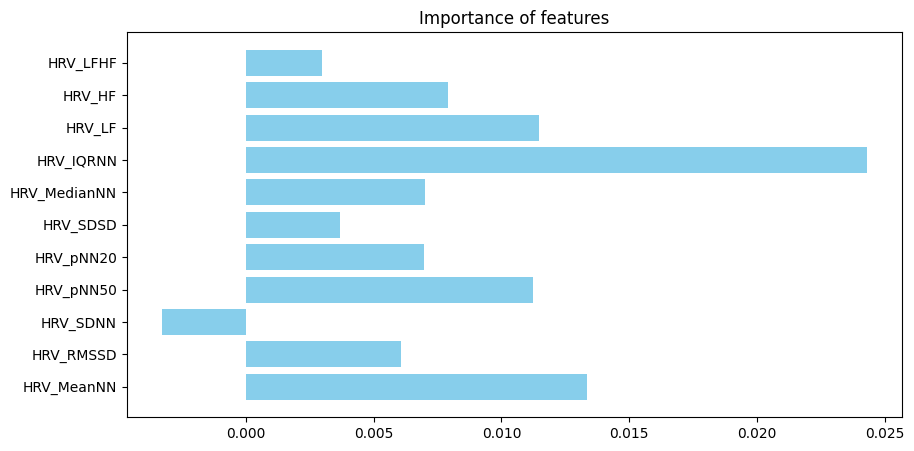

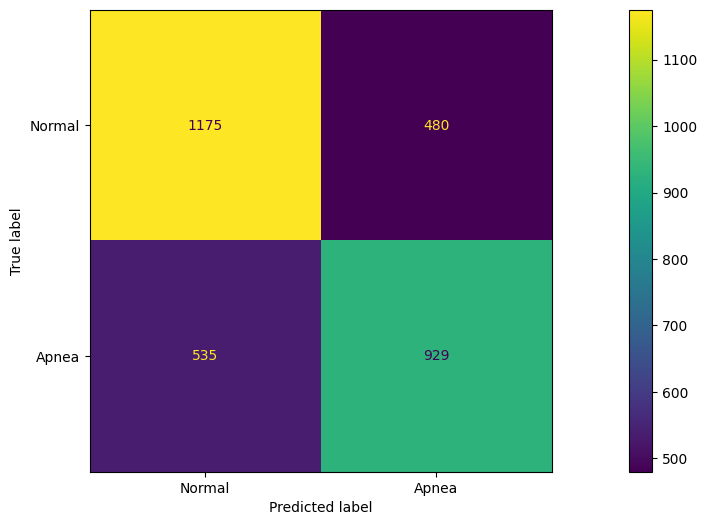

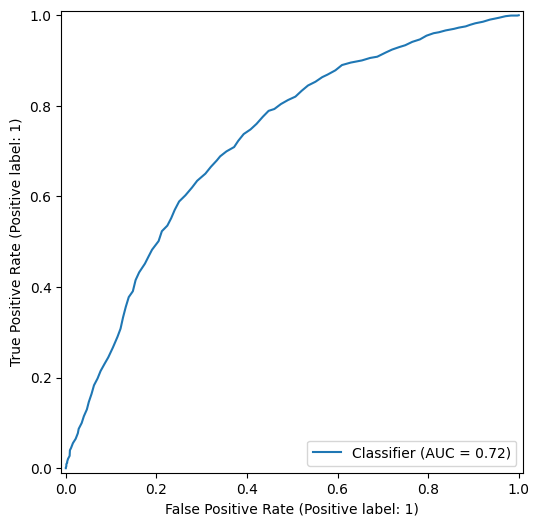

In [169]:
rf = predict_and_evaluate_all(X_train, y_train, X_test, y_test, model=clf, group=groups)

Accuracy: 0.687
Precision: 0.670
Recall: 0.657
F1 score: 0.663
AUC: 0.735


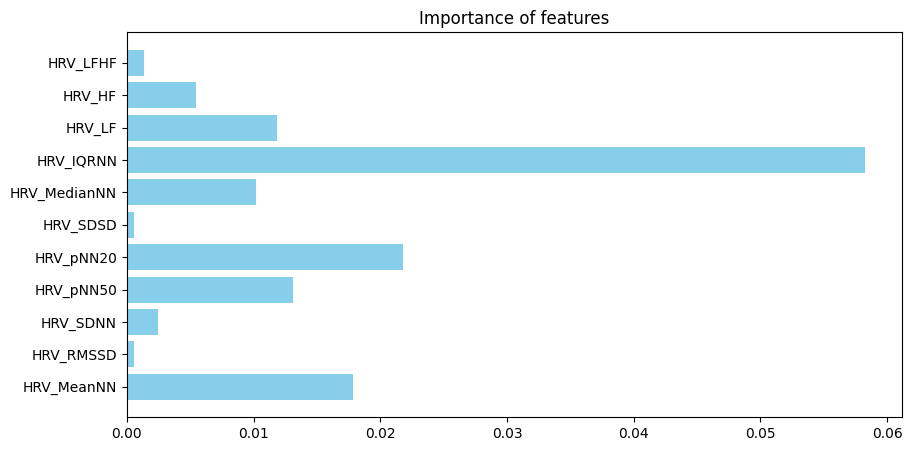

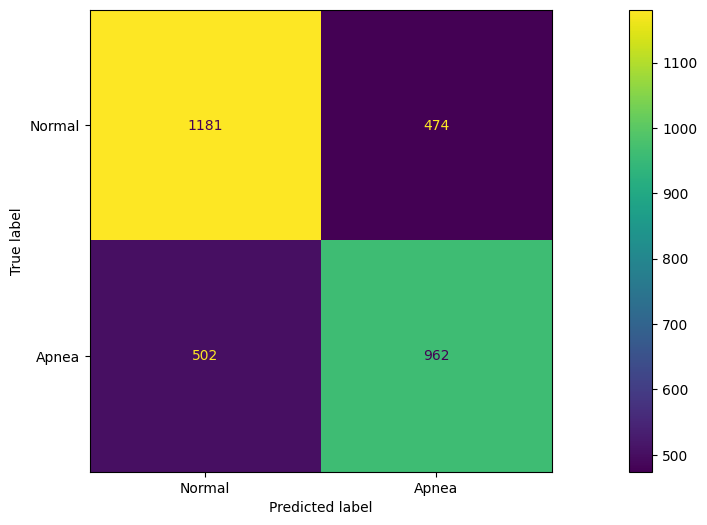

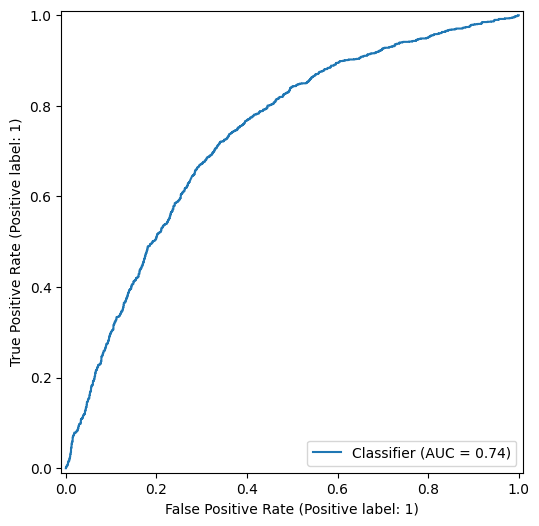

In [170]:
svm = predict_and_evaluate_all(X_train, y_train, X_test, y_test, model=svc, group=groups)

#### Evaluation of the machine learning methods and the results
The most impactful features on RF were inter-quartile range, mean, and LF/pNN50. SVM was the most influenced by mean, inter-quartile range and pNN20. Finer evaluation of feature importance could be useful if this method would be developed further. As feature importance wasn't required in this project, we won't evaluate it further.

The accuracy acquired with RF was 67,5 % which is not a create accuracy. The accuracy conducted by the SVM was 68,7 % which was slightly better than with RF. With both models, the precision, recall and F1 score were pretty much the same (between 0.641 and 0.670). Good thing is that the F1 score is close to precision and recall scores which indicates that either precision or recall weren't much worse than the other. On the other hand, in both cases the recall was slightly worse than precision which indicates that the models are producing some false negatives, but missing more true positives. This is the worst case in health monitoring as the models miss sick patients. 

AUC presented the performance of the classifier, and as RF AUC score was 0.72 SVM performed a bit better with a 0.74 score. As the scores were above 0.5, the classifiers performed better than a random guess. However, the results aren't still very good compared to the articles (1), (2), (6) results. On the other hand, we didn't use any exact project line presented in the research projects (1), (2), (6). There is many variables which could have affected the results. 

In this project, we used same kind of parameters as in the literature excluding the use of nonlinear parameters. We first tested with fewer parameters (SDNN, RMSSD, pNN50, LF, HF, and LF/HF ratio), but this didn't affect the classifier performance. There might be outliers that have affected the results. If that's the case, the filtering of the ecg signal should be improved or changed. Furthermore, steps like feature selection or comparing more different ML models could have led us to better results. 

### Conclusions

This project contained sleep apnea detection from ECG data by first extracting HRV features and then applying machine learning methods. The main methods used were prerocessing of ECG data, peak detection, extraction of HRV features, and finally the implementation of machine learning methods. Unbiasedness of the data in applying ML methods was secured by Leave-Group-Out validation along with random shuffle. The neurokit pakages were heavily used in the project.

Four classifiers were tested from which Random Forest and Support Vector Machine were chosen by the accuracy score. Still, the results obtained weren't very good compared to earlier research (1), (2), (6). On the other hand, our project wasn't executed using completely the same methods as in some other project (1), (2), (6). Following completely the steps in some other project, could have helped us to obtain better results. There is many possible reasons for worse results e.g., bad choice of HRV features or poor filtering of outliers.

In conclusion, the methods developed in this project work aren't qualified for sleep apnea detection. Especially, the relation between precision and recall raises a guestion about the safeness of this implementation for reliable health monitoring. If we were to continue this project further, next step would be in improving the classifier performance by examining the HRV features and filtering choices, and to go deeper into the shortcomings of our approaches.

## References

- (1) Tyagi, P.K. & Agrawal, D. (2024) ‘Automatic detection of sleep apnea from a single-lead ECG signal based on spiking neural network model’, Computers in Biology and Medicine, 179, 108877. doi:10.1016/j.compbiomed.2024.108877 

- (2) Almazaydeh, L., Elleithy, K. & Faezipour, M. (2012) ‘Detection of obstructive sleep apnea through ECG signal features’, in Proceedings of the 2012 IEEE International Conference on Electro/Information Technology (EIT), Indianapolis, IN, USA, pp. 1–6. doi:10.1109/EIT.2012.6220730

- (3) Henoch, J. (2025) ‘Tachycardia vs. bradycardia’, Mass General Brigham – Newsroom, 6 October. Available at: https://www.massgeneralbrigham.org/en/about/newsroom/articles/tachycardia-vs-bradycardia, Accessed: 19 April 2026.

- (4) Maier, C., Bauch, M. & Dickhaus, H. (2000) ‘Recognition and quantification of sleep apnea by analysis of heart rate variability parameters’, in Computers in Cardiology 2000 (Vol. 27), Cambridge, MA, USA, pp. 741–744. doi:10.1109/CIC.2000.898631

- (5) Daskalov, I. & Christov, I. (1997) ‘Improvement of resolution in measurement of electrocardiogram RR intervals by interpolation’, Medical Engineering & Physics, 19(4), pp. 375–379. doi:10.1016/S1350-4533(96)00067-7

- (6) Attar, E.T. (2025) ‘Detailed evaluation of sleep apnea using heart rate variability: a machine learning and statistical method using ECG data’, Frontiers in Neurology, 16, 1636983. doi:10.3389/fneur.2025.1636983

- (7) Liu, K., Jiao, Y., Du, C., Zhang, X., Chen, X., Xu, F. & Jiang, C. (2023) ‘Driver stress detection using ultra-short-term HRV analysis under real world driving conditions’, Entropy, 25(2), 194. doi:10.3390/e25020194

## Reference websites used for coding
- https://www.geeksforgeeks.org/
- https://www.w3schools.com/
- https://scikit-learn.org/
- https://neuropsychology.github.io/NeuroKit/examples/ecg_hrv/ecg_hrv.html
- https://www.kaggle.com/
- https://coralogix.com/
- https://machinelearningmastery.com/
- https://medium.com/